<a href="https://colab.research.google.com/github/Varun-Chandrasekar/Peptide-Properties/blob/main/RNA_Peptide_Intraction_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Install and Import Libraries

In [1]:
!pip install -q torch seaborn

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 885.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00


## Step 2: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 3: Define RNA and Peptide Vocabularies

In [3]:
rna_vocab = {'A': 0, 'U': 1, 'G': 2, 'C': 3}
pep_vocab = {aa: idx for idx, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}

## Step 4: Define Dual Encoder Model

In [4]:
class SimpleEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleEncoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        return hidden.squeeze(0)

class DualEncoderWithInteraction(nn.Module):
    def __init__(self, vocab_size_rna, vocab_size_pep, embed_dim=16, hidden_dim=32):
        super(DualEncoderWithInteraction, self).__init__()
        self.rna_encoder = SimpleEncoder(vocab_size_rna, embed_dim, hidden_dim)
        self.pep_encoder = SimpleEncoder(vocab_size_pep, embed_dim, hidden_dim)
        self.interaction_layer = nn.CosineSimilarity(dim=1)
        self.fc = nn.Linear(1, 1)

    def forward(self, rna_seq, pep_seq):
        rna_vec = self.rna_encoder(rna_seq)
        pep_vec = self.pep_encoder(pep_seq)
        interaction = self.interaction_layer(rna_vec, pep_vec).unsqueeze(1)
        output = self.fc(interaction)
        return torch.sigmoid(output).squeeze(1), interaction.squeeze(1)

## Step 5: Load Trained Model from Google Drive

In [7]:
model = DualEncoderWithInteraction(len(rna_vocab), len(pep_vocab))
model_path = '/content/drive/MyDrive/dual_encoder_model_with_interaction.pth'
model.load_state_dict(torch.load(model_path, map_location='cpu'))
model.eval()

DualEncoderWithInteraction(
  (rna_encoder): SimpleEncoder(
    (embedding): Embedding(4, 16)
    (lstm): LSTM(16, 32, batch_first=True)
  )
  (pep_encoder): SimpleEncoder(
    (embedding): Embedding(20, 16)
    (lstm): LSTM(16, 32, batch_first=True)
  )
  (interaction_layer): CosineSimilarity()
  (fc): Linear(in_features=1, out_features=1, bias=True)
)

## Step 6: Define Helper Functions

In [8]:
def encode_sequence(seq, vocab):
    return torch.tensor([vocab[c] for c in seq if c in vocab]).unsqueeze(0)

def model_predict_interaction_score(rna_base, pep_residue):
    rna_tensor = encode_sequence(rna_base, rna_vocab)
    pep_tensor = encode_sequence(pep_residue, pep_vocab)
    with torch.no_grad():
        _, interaction = model(rna_tensor, pep_tensor)
    return interaction.item()

def predict_interaction_matrix(peptide_seq, rna_seq):
    L_p, L_r = len(peptide_seq), len(rna_seq)
    matrix = np.zeros((L_p, L_r))
    for i, pep_res in enumerate(peptide_seq):
        for j, rna_base in enumerate(rna_seq):
            matrix[i, j] = model_predict_interaction_score(rna_base, pep_res)
    return matrix

def visualize_interaction_matrix(matrix, peptide_seq, rna_seq, title="Predicted RNA–Peptide Interaction Map"):
    plt.figure(figsize=(12, 6))
    sns.heatmap(matrix, xticklabels=list(rna_seq), yticklabels=list(peptide_seq),
                cmap='viridis', cbar_kws={'label': 'Cosine Similarity'})
    plt.title(title)
    plt.xlabel("RNA Sequence")
    plt.ylabel("Peptide Sequence")
    plt.tight_layout()
    plt.show()

## Step 7: Enter Sequences and Generate Heatmap

Enter RNA sequence (e.g., AUGCUA): AUGCUA
Enter peptide sequence (e.g., ACDEFGHIK): ACDEFGHIK


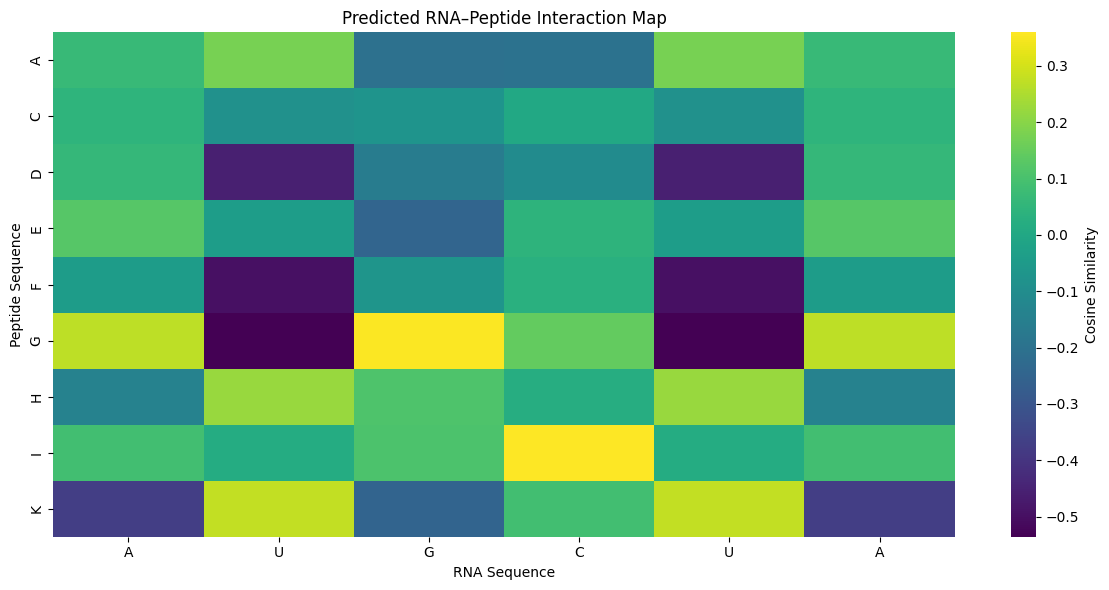

In [9]:
rna_sequence = input("Enter RNA sequence (e.g., AUGCUA): ").strip().upper()
peptide_sequence = input("Enter peptide sequence (e.g., ACDEFGHIK): ").strip().upper()

contact_matrix = predict_interaction_matrix(peptide_sequence, rna_sequence)
visualize_interaction_matrix(contact_matrix, peptide_sequence, rna_sequence)